# Eksperimen Machine Learning - California Housing Dataset
**Nama:** Athalie Aurora

Notebook ini mengikuti Template Eksperimen MSML yang mencakup:
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Kesimpulan

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Data Loading

In [2]:
# Load dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# Simpan raw data
os.makedirs('../california_housing_raw', exist_ok=True)
df.to_csv('../california_housing_raw/california_housing_raw.csv', index=False)

print(f'Dataset shape: {df.shape}')
print(f'\nFeatures: {california.feature_names}')
print(f'Target: MedHouseVal (Median House Value)')
df.head()

Dataset shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal (Median House Value)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Statistik deskriptif
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Cek missing values
print('Missing Values per Column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing Values per Column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing values: 0


In [6]:
# Cek duplikat
print(f'Jumlah duplikat: {df.duplicated().sum()}')

Jumlah duplikat: 0


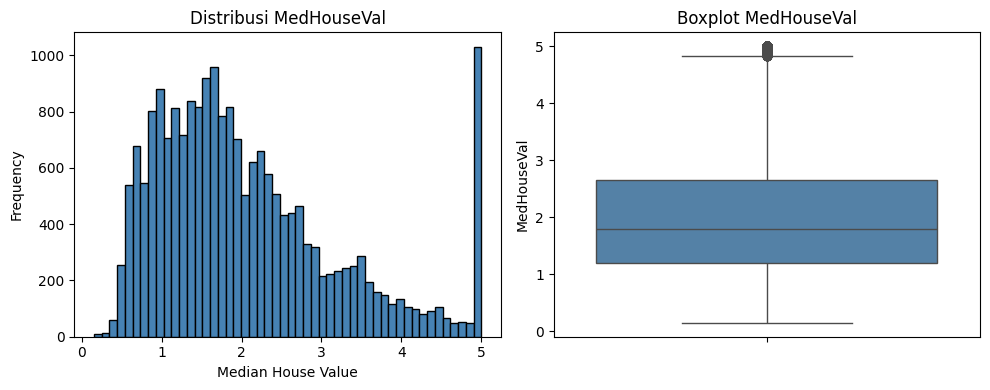

In [7]:
# Distribusi target variable
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribusi MedHouseVal')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['MedHouseVal'], color='steelblue')
plt.title('Boxplot MedHouseVal')

plt.tight_layout()
plt.show()

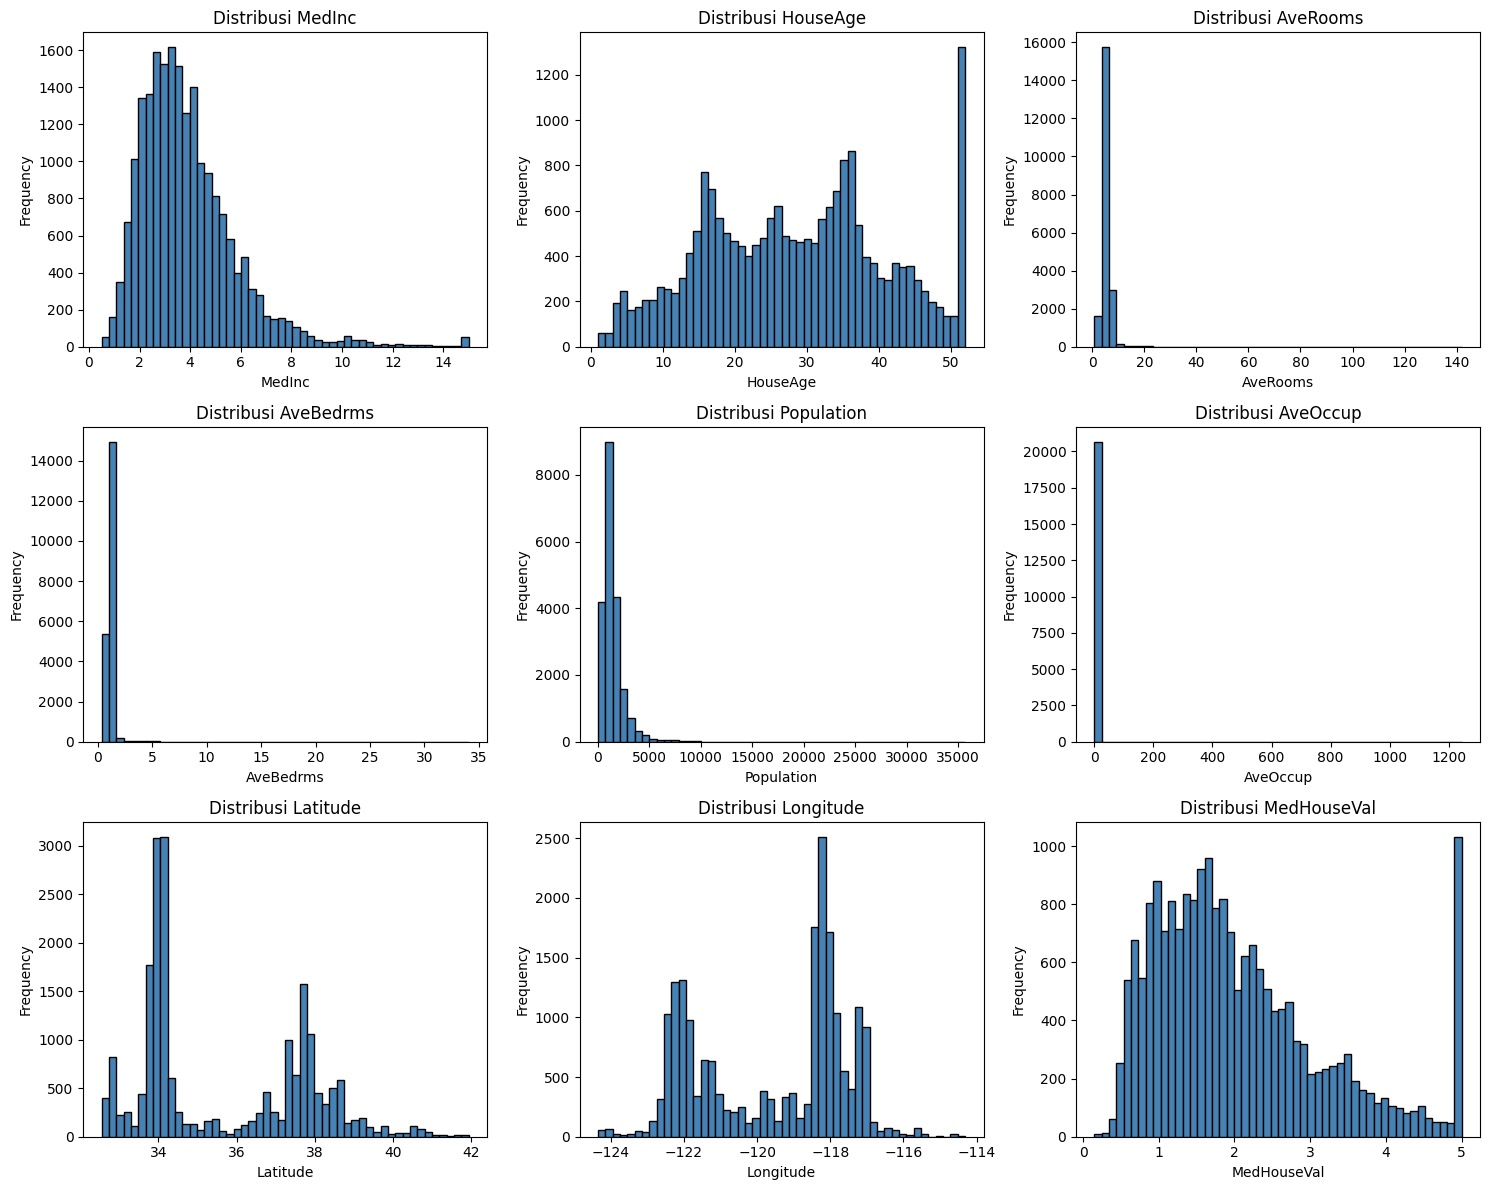

In [8]:
# Distribusi semua fitur
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

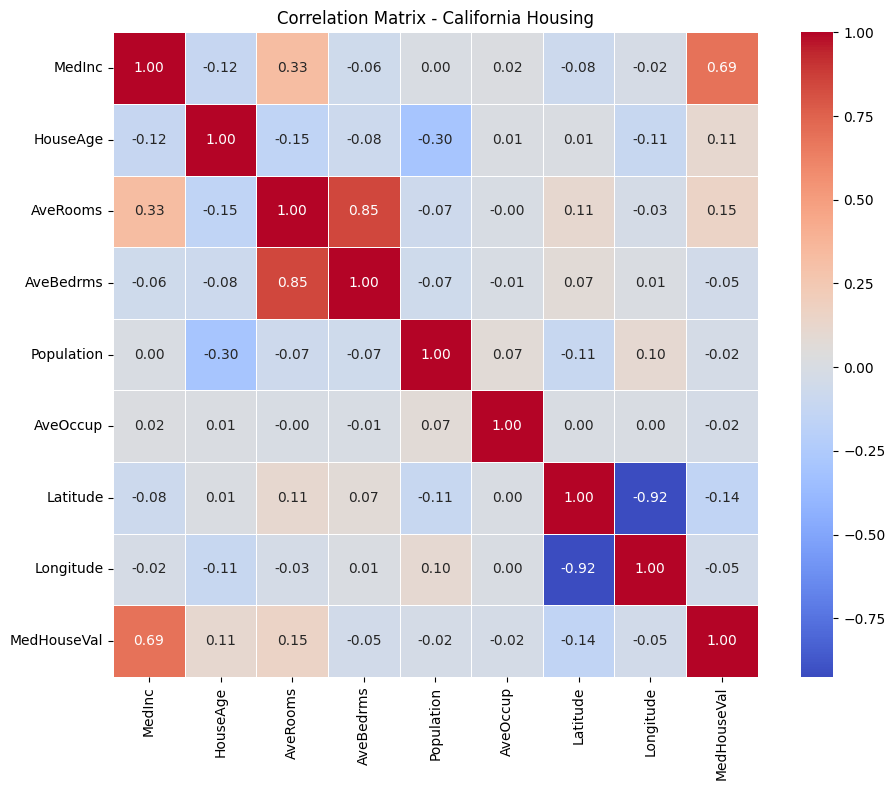

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - California Housing')
plt.tight_layout()
plt.show()

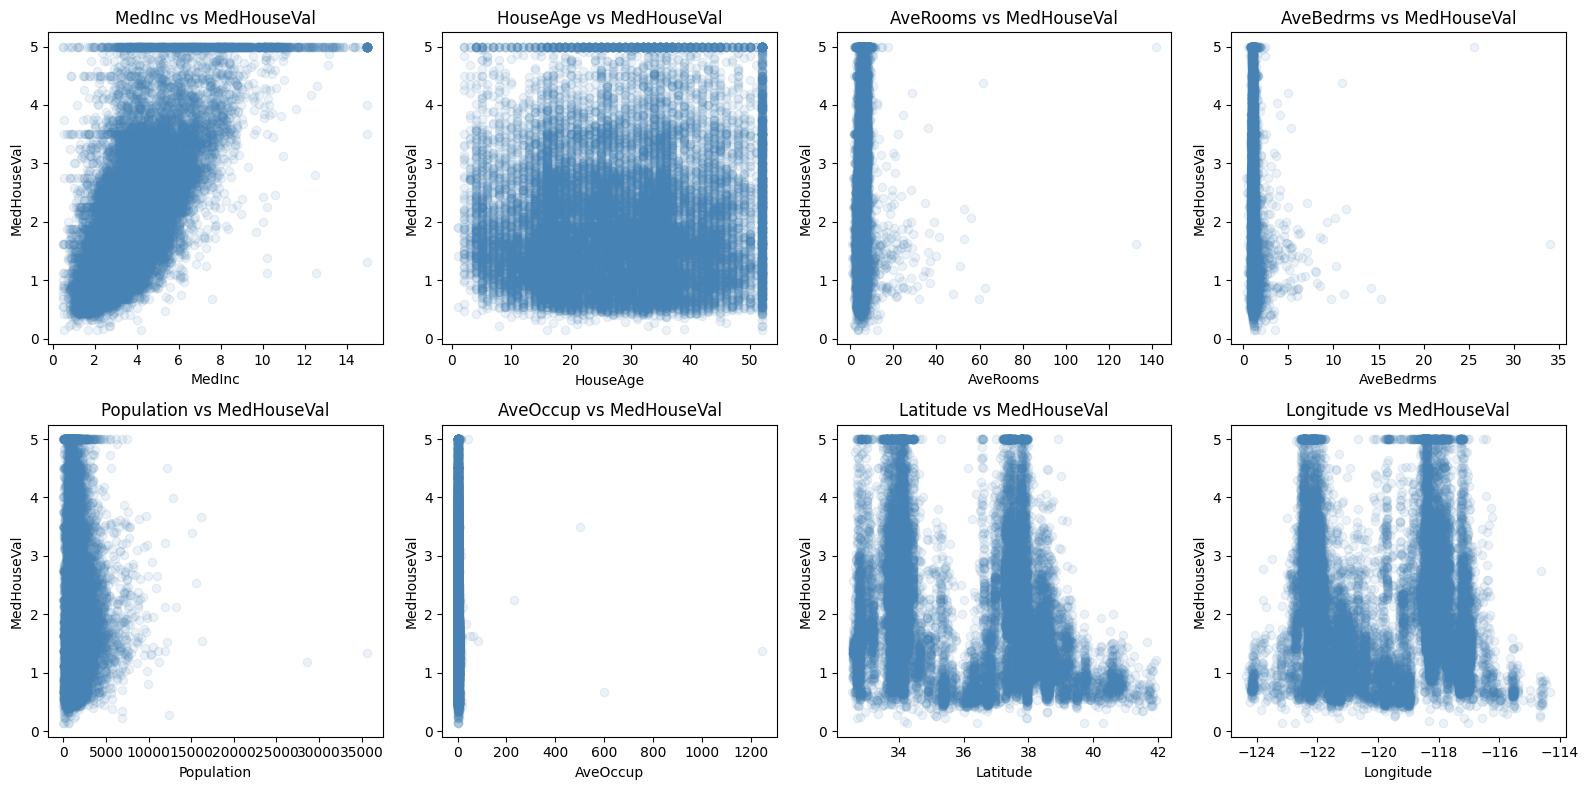

In [10]:
# Scatter plot fitur vs target
features = california.feature_names
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['MedHouseVal'], alpha=0.1, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('MedHouseVal')
    axes[i].set_title(f'{feat} vs MedHouseVal')

plt.tight_layout()
plt.show()

In [11]:
# Deteksi outlier dengan IQR
print('Deteksi Outlier (IQR Method):')
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'  {col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)')

Deteksi Outlier (IQR Method):
  MedInc: 681 outliers (3.30%)
  HouseAge: 0 outliers (0.00%)
  AveRooms: 511 outliers (2.48%)
  AveBedrms: 1424 outliers (6.90%)
  Population: 1196 outliers (5.79%)
  AveOccup: 711 outliers (3.44%)
  Latitude: 0 outliers (0.00%)
  Longitude: 0 outliers (0.00%)
  MedHouseVal: 1071 outliers (5.19%)


## 4. Data Preprocessing

In [12]:
# Pisahkan fitur dan target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')

Shape X: (20640, 8)
Shape y: (20640,)


In [13]:
# Handle missing values (imputation)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

print('Missing values setelah imputation:')
print(X_imputed.isnull().sum())

Missing values setelah imputation:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [14]:
# Handle outlier dengan clipping (IQR)
def clip_outliers(df_input):
    df_clipped = df_input.copy()
    for col in df_clipped.columns:
        Q1 = df_clipped[col].quantile(0.25)
        Q3 = df_clipped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clipped[col] = df_clipped[col].clip(lower, upper)
    return df_clipped

X_clipped = clip_outliers(X_imputed)
print('Outlier handling selesai.')
X_clipped.describe()

Outlier handling selesai.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.801010,28.639486,5.304740,1.057958,1336.959012,2.899647,35.631861,-119.569704
std,1.657658,12.585558,1.246177,0.080448,765.550830,0.691142,2.135952,2.003532
min,0.499900,1.000000,2.023219,0.865909,3.000000,1.150961,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,8.013025,52.000000,8.469878,1.239697,3132.000000,4.561041,41.950000,-114.310000


In [15]:
# Feature Engineering: tambah fitur baru
X_clipped['RoomsPerHousehold'] = X_clipped['AveRooms'] / X_clipped['HouseAge'].replace(0, 1)
X_clipped['BedroomsPerRoom'] = X_clipped['AveBedrms'] / X_clipped['AveRooms'].replace(0, 1)
X_clipped['PopulationPerHousehold'] = X_clipped['Population'] / X_clipped['AveOccup'].replace(0, 1)

print(f'Shape setelah feature engineering: {X_clipped.shape}')
X_clipped.head()

Shape setelah feature engineering: (20640, 11)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold
0,8.013025,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0.170345,0.146591,126.0
1,8.013025,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,0.297054,0.155797,1138.0
2,7.257400,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0.159387,0.129516,177.0
3,5.643100,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,0.111872,0.184458,219.0
4,3.846200,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,0.120805,0.172096,259.0


In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clipped, y, test_size=0.2, random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (16512, 11)
X_test shape:  (4128, 11)


In [17]:
# Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_clipped.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_clipped.columns)

print('Scaling selesai.')
X_train_scaled.describe()

Scaling selesai.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold
count,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04
mean,-7.186327e-17,-9.251859e-18,5.084757e-16,-3.333251e-15,1.545921e-16,2.934776e-16,6.400995e-17,1.753335e-15,2.818589e-17,9.488534e-17,-1.963330e-16
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-1.991856e+00,-2.190766e+00,-2.639680e+00,-2.389174e+00,-1.745219e+00,-2.528402e+00,-1.447697e+00,-2.377207e+00,-7.173405e-01,-1.865031e+00,-1.703242e+00
25%,-7.485134e-01,-8.417859e-01,-6.910742e-01,-6.450164e-01,-7.177057e-01,-6.791053e-01,-8.018107e-01,-1.110749e+00,-4.444034e-01,-6.785105e-01,-6.922261e-01
50%,-1.595078e-01,3.108328e-02,-6.223208e-02,-1.143477e-01,-2.235583e-01,-1.169506e-01,-6.473597e-01,5.346501e-01,-2.865405e-01,-1.790473e-01,-2.228258e-01
75%,5.788548e-01,6.658972e-01,5.997798e-01,5.190856e-01,5.072048e-01,5.527599e-01,9.720351e-01,7.839530e-01,8.555893e-02,4.826152e-01,4.848854e-01
max,2.527879e+00,1.856173e+00,2.532345e+00,2.247737e+00,2.345224e+00,2.406692e+00,2.951816e+00,2.628794e+00,2.503913e+01,7.054869e+00,6.458698e+00


In [18]:
# Simpan hasil preprocessing
os.makedirs('california_housing_preprocessing', exist_ok=True)

train_df = X_train_scaled.copy()
train_df['MedHouseVal'] = y_train.values

test_df = X_test_scaled.copy()
test_df['MedHouseVal'] = y_test.values

train_df.to_csv('california_housing_preprocessing/train.csv', index=False)
test_df.to_csv('california_housing_preprocessing/test.csv', index=False)

print(f'Train set saved: {train_df.shape}')
print(f'Test set saved:  {test_df.shape}')

Train set saved: (16512, 12)
Test set saved:  (4128, 12)


## 5. Kesimpulan

- Dataset California Housing memiliki **20.640 baris** dan **8 fitur** numerik.
- **Tidak ada missing values** pada dataset ini.
- Terdapat outlier pada beberapa fitur seperti `AveRooms`, `AveBedrms`, dan `Population` yang sudah ditangani dengan metode IQR clipping.
- Ditambahkan **3 fitur baru** hasil feature engineering: `RoomsPerHousehold`, `BedroomsPerRoom`, `PopulationPerHousehold`.
- Data dibagi menjadi **80% train** dan **20% test**.
- Fitur dinormalisasi menggunakan **StandardScaler**.
- Dataset siap digunakan untuk pelatihan model regresi.